First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


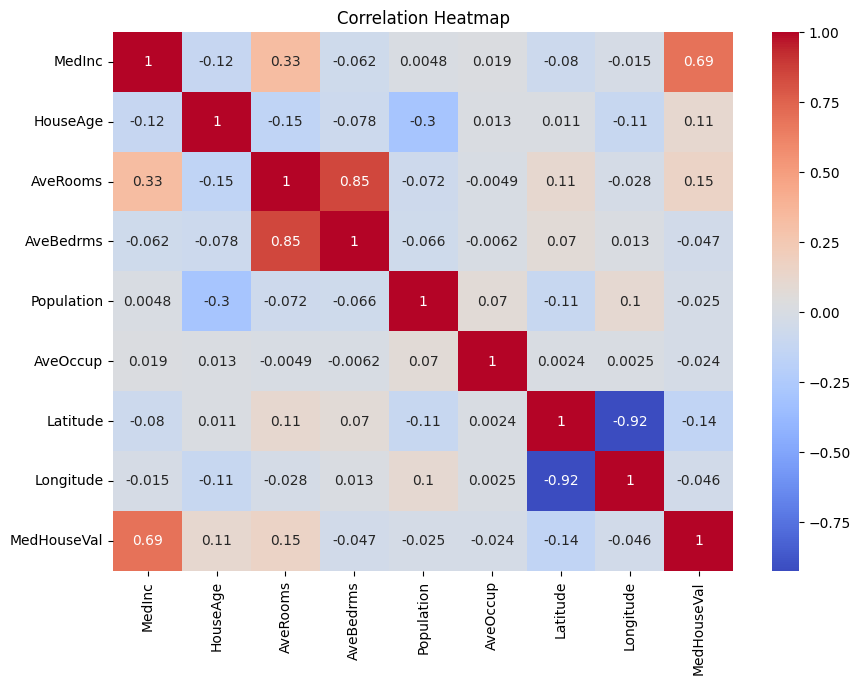

Feature Scaling Completed!

Model Comparison Results:


,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


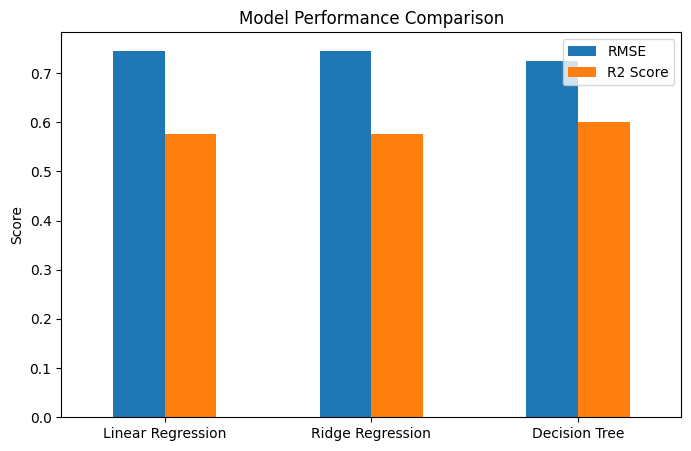

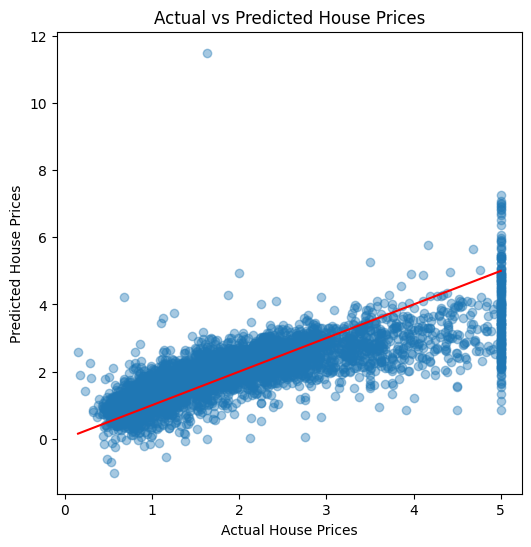

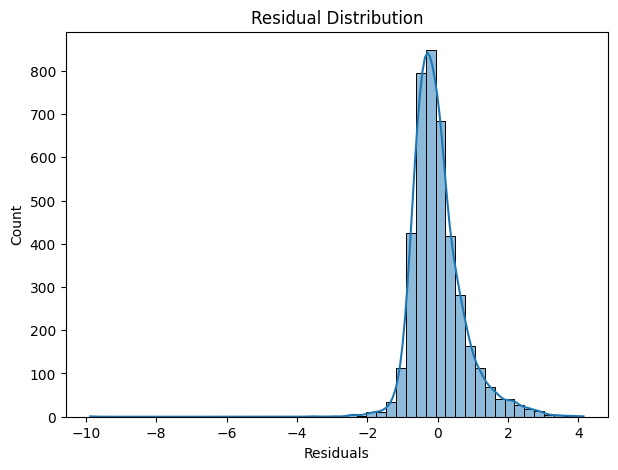


Best model saved successfully!


In [1]:
# =====================================================
# TASK 2
# FEATURE ENGINEERING, MODEL OPTIMIZATION
# & PERFORMANCE COMPARISON
# =====================================================

# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

# =====================================================
# 2. LOAD DATASET
# =====================================================

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("First 5 Rows:")
display(df.head())

# =====================================================
# 3. DATASET INFORMATION
# =====================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

# =====================================================
# 4. CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(10,7))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# =====================================================
# 5. FEATURES AND TARGET
# =====================================================

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

# =====================================================
# 6. FEATURE SCALING
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed!")

# =====================================================
# 7. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 8. TRAIN MULTIPLE MODELS
# =====================================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Decision Tree": DecisionTreeRegressor(max_depth=5)

}

# =====================================================
# 9. MODEL EVALUATION
# =====================================================

results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    # Store results
    results[name] = {

        "RMSE": rmse,

        "R2 Score": r2
    }

# =====================================================
# 10. RESULTS TABLE
# =====================================================

results_df = pd.DataFrame(results).T

print("\nModel Comparison Results:")

display(results_df)

# =====================================================
# 11. BAR CHART COMPARISON
# =====================================================

results_df.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

# =====================================================
# 12. BEST MODEL VISUALIZATION
# =====================================================

best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Actual vs Predicted Plot

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")

plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

# =====================================================
# 13. RESIDUAL DISTRIBUTION
# =====================================================

residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.histplot(residuals, bins=50, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

# =====================================================
# 14. SAVE BEST MODEL (OPTIONAL)
# =====================================================

import pickle

with open("best_model.pkl", "wb") as file:

    pickle.dump(best_model, file)

print("\nBest model saved successfully!")